### **Aspekty aplikacyjne FFT - przeciek widma**

FFT zakłada, że analizowany sygnał jest okresowy w oknie obserwacji.

Jeśli nie jest — pojawia się „skok” na końcach:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

In [27]:
fs = 100
N = 200
t = np.arange(N) / fs

In [29]:
# przypadek 1: idealny (10 Hz → całkowita liczba okresów)
signal_clean = np.sin(2*np.pi*10*t)

In [31]:
# przypadek 2: nieidealny (10.3 Hz)
signal_leak = np.sin(2*np.pi*10.3*t)

In [33]:
def compute_fft(signal):
    X = rfft(signal)
    freqs = rfftfreq(len(signal), 1/fs)
    amp = (2.0 / len(signal)) * np.abs(X)
    return freqs, amp

In [35]:
f1, a1 = compute_fft(signal_clean)
f2, a2 = compute_fft(signal_leak)

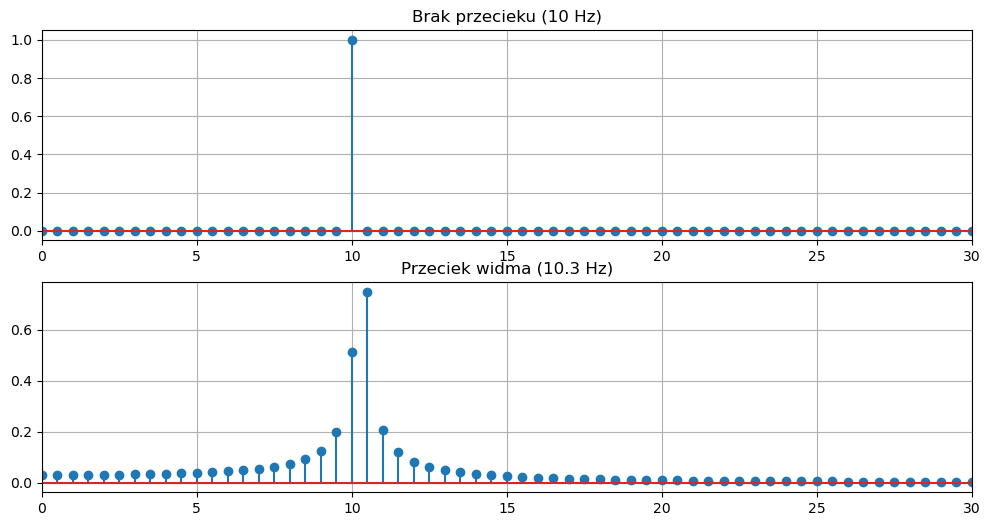

In [39]:
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.stem(f1, a1)
plt.title("Brak przecieku (10 Hz)")
plt.xlim(0, 30)
plt.grid()

plt.subplot(2,1,2)
plt.stem(f2, a2)
plt.title("Przeciek widma (10.3 Hz)")
plt.xlim(0, 30)
plt.grid()

### **Okno Hahna**

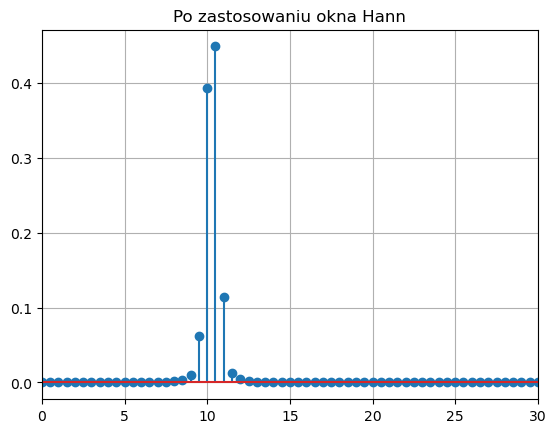

In [44]:
window = np.hanning(N)
signal_windowed = signal_leak * window

f, a = compute_fft(signal_windowed)

plt.stem(f, a)
plt.xlim(0, 30)
plt.title("Po zastosowaniu okna Hann")
plt.grid()
plt.show()

### **Porównanie okien funkcyjnych**

Okna zmniejszają przeciek widma, ale kosztem:

- szerszego piku (gorsza rozdzielczość)
- zmiany amplitudy

In [48]:
# okna
windows = {
    "Rectangular": np.ones(N),
    "Hann": np.hanning(N),
    "Hamming": np.hamming(N),
    "Blackman": np.blackman(N),
}

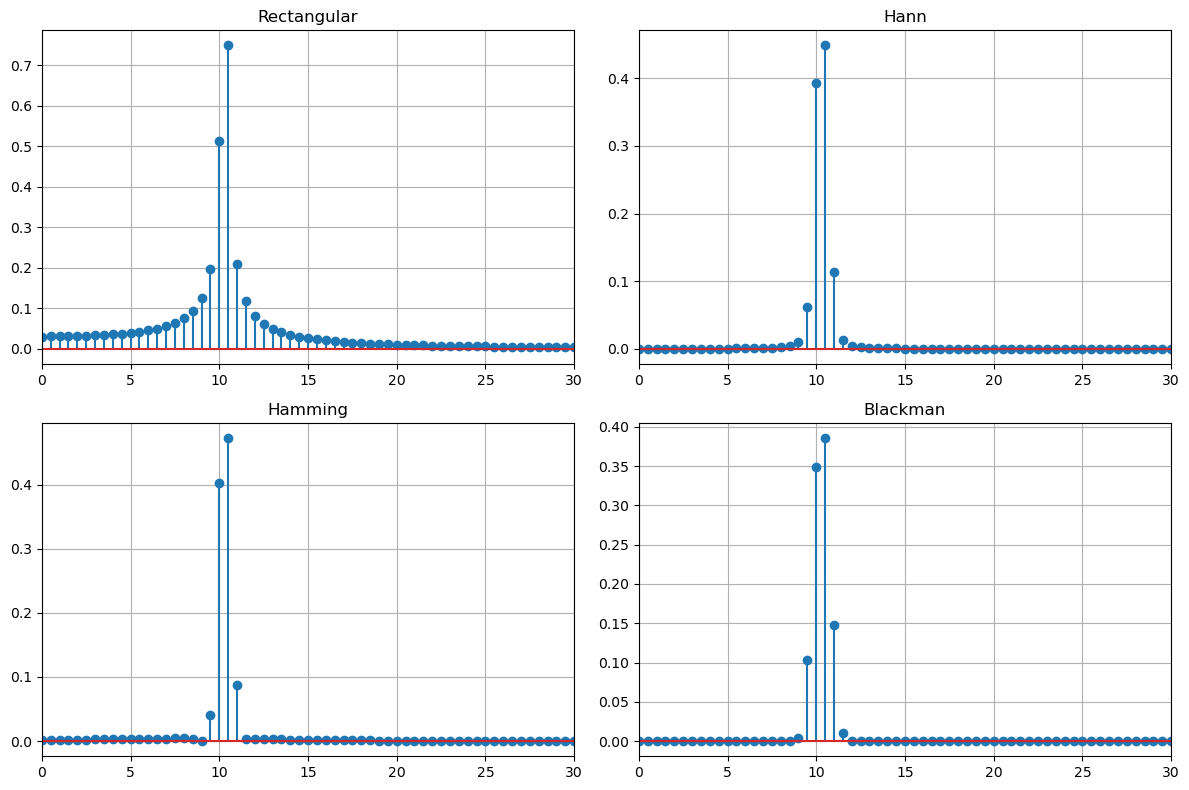

In [56]:
plt.figure(figsize=(12,8))
for i, (name, w) in enumerate(windows.items()):
    sig_w = signal_leak * w
    f, a = compute_fft(sig_w)
    
    plt.subplot(2,2,i+1)
    plt.stem(f, a)
    plt.title(name)
    plt.xlim(0, 30)
    plt.grid()

plt.tight_layout()
plt.show()